# Polynomial global optimization with `pounce.sos_minimize`

Most of POUNCE finds a **local** optimum. For **polynomial** objectives and
constraints, `pounce.sos_minimize` instead returns a *certified global* lower
bound — and, when the relaxation is exact, the global minimizer(s) themselves.

It does this with the **sum-of-squares / Lasserre** moment relaxation: the
nonconvex polynomial program is lifted to a single semidefinite program (solved
by POUNCE's own convex conic IPM, `pounce-convex`). The SDP's optimum is a lower
bound on the true minimum; a **flat-truncation** test certifies when that bound
is exact, and a facial-reduction step recovers every global minimizer — even
when the optimum is attained at several points.

> **Scope.** This is for *polynomials*. For general factorable nonconvex
> problems (with `exp`/`log`/trig), the spatial branch-and-bound solver
> (`pounce-global`) is the tool — see `docs/src/global-optimization.md`.


## Writing a polynomial

A polynomial is a **dict mapping an exponent tuple to its coefficient**. Over
variables $(x, y)$ the term $3\,x^2 y$ is `(2, 1): 3.0`, and a constant is the
all-zeros key. So $x^4 - 2x^2 + 3$ over one variable is:


In [1]:
from pounce.sos import sos_minimize

# x**4 - 2 x**2 + 3
objective = {(4,): 1.0, (2,): -2.0, (0,): 3.0}

## A double well: two global minimizers

$f(x) = x^4 - 2x^2 + 3$ is the classic double well. Its global minimum is
$2$, attained at **both** $x = +1$ and $x = -1$. SOS finds the bound *and*
recovers both minimizers — something a local solver started from one basin
never sees.


In [2]:
r = sos_minimize(objective)

print(f"lower_bound      = {r.lower_bound:.6f}")
print(f"is_exact         = {r.is_exact}        # flat-truncation certificate")
print(f"num_minimizers   = {r.num_minimizers}")
print(f"minimizers       = {[m.round(6) for m in r.minimizers]}")
print(f"status / success = {r.status} / {r.success}")

lower_bound      = 2.000000
is_exact         = True        # flat-truncation certificate
num_minimizers   = 2
minimizers       = [array([-1.]), array([1.])]
status / success = optimal / True


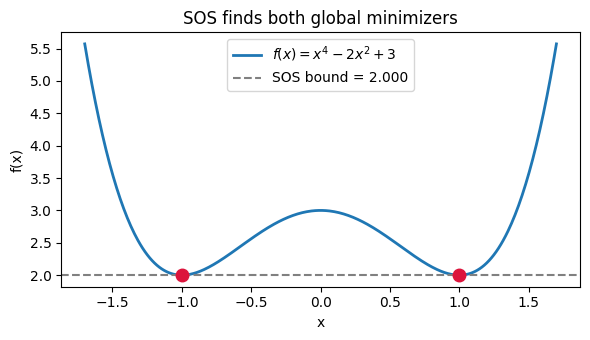

In [3]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-1.7, 1.7, 400)
fs = xs**4 - 2*xs**2 + 3

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(xs, fs, lw=2, label=r"$f(x)=x^4-2x^2+3$")
ax.axhline(r.lower_bound, ls="--", color="gray", label=f"SOS bound = {r.lower_bound:.3f}")
for m in r.minimizers:
    ax.plot(m[0], m[0]**4 - 2*m[0]**2 + 3, "o", color="crimson", ms=9)
ax.set(xlabel="x", ylabel="f(x)", title="SOS finds both global minimizers")
ax.legend(loc="upper center")
fig.tight_layout()

## Constrained polynomial optimization

Constraints are polynomials too, passed as `inequalities` ($g_i(x) \ge 0$) and
`equalities` ($h_j(x) = 0$). Minimize $-x$ subject to $1 - x^2 \ge 0$ (i.e.
$x \in [-1, 1]$) — the answer is $-1$ at $x = 1$:


In [4]:
r_con = sos_minimize(
    {(1,): -1.0},                       # objective: -x
    inequalities=[{(0,): 1.0, (2,): -1.0}],  # 1 - x**2 >= 0
)
print(f"min (-x) over [-1, 1]  ->  {r_con.lower_bound:.6f} at x = {r_con.minimizers[0].round(6)}")

min (-x) over [-1, 1]  ->  -1.000000 at x = [1.]


## Two variables

The dict format scales to any number of variables; pass `n_vars` when it can't
be inferred. Here is a small 2-D quadratic, $f(x,y) = x^2 + y^2 - xy - x$:


In [5]:
r2 = sos_minimize(
    {(2, 0): 1.0, (0, 2): 1.0, (1, 1): -1.0, (1, 0): -1.0},
    n_vars=2,
)
print(f"lower_bound = {r2.lower_bound:.6f}")
print(f"minimizer   = {r2.minimizers[0].round(4)}")

lower_bound = -0.333333
minimizer   = [0.6667 0.3333]


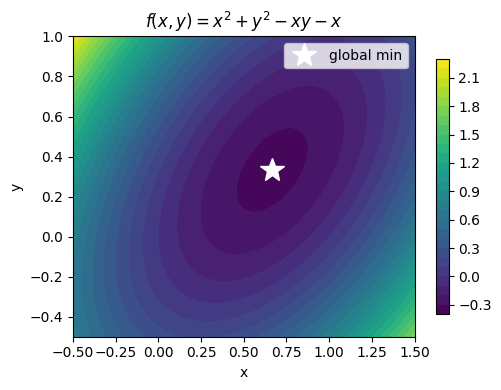

In [6]:
# Visualize the 2-D surface and the recovered minimizer.
gx = np.linspace(-0.5, 1.5, 200)
gy = np.linspace(-0.5, 1.0, 200)
GX, GY = np.meshgrid(gx, gy)
F = GX**2 + GY**2 - GX*GY - GX

fig, ax = plt.subplots(figsize=(5.2, 4))
cs = ax.contourf(GX, GY, F, levels=30, cmap="viridis")
m = r2.minimizers[0]
ax.plot(m[0], m[1], "*", color="white", ms=18, label="global min")
ax.set(xlabel="x", ylabel="y", title=r"$f(x,y)=x^2+y^2-xy-x$")
ax.legend()
fig.colorbar(cs, ax=ax, shrink=0.85)
fig.tight_layout()

## The `is_exact` certificate

`lower_bound` is *always* a valid lower bound on the global minimum. When
`is_exact` is `True`, flat truncation has certified the relaxation is tight, so
`lower_bound` **equals** the global minimum and `minimizers` are the true global
optima. When it is `False`, you still have a rigorous bound — raise the
relaxation `order` (the Lasserre hierarchy) to tighten it, at the cost of a
larger SDP.

```python
r = sos_minimize(objective, order=3)   # higher order -> tighter bound
```

## When to use SOS vs. branch-and-bound

| | `sos_minimize` (this notebook) | `pounce-global` (spatial B&B) |
|---|---|---|
| Problem | polynomials, modest degree/dim | general factorable (`exp`/`log`/trig) |
| Method | one SDP (moment relaxation) | branch-and-bound with αBB underestimators |
| Returns | all global minimizers when exact | one certified global optimum |
| Python API | **yes**, `pounce.sos_minimize` | not yet wired — see `docs/src/global-optimization.md` |

See `docs/src/global-optimization.md` and `docs/src/convex-solver.md` for the
full treatment.
